In [1]:
# Load only the compact, checksummed paper snapshot. No network or simulations.
from pathlib import Path
import sys
import csv
import hashlib
import json
import statistics
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.path import Path as MplPath
import numpy as np
from IPython.display import SVG, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "results/paper/paper-v1/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "analyses"))
import paper_plots
from paper_plots import (ARMS, NAMES, ADDITION_COLORS, COMPACT_WIDTH, WRAPPED_NAMES,
                         style, save, csv_table, check_figure_text, gem5_mode_means,
                         PLOTTING_SOURCE)
from paper_workflow import (WIDTH, HEIGHT, LAYOUT_HEIGHT, INK, TEAL, MUTED, LINE,
                            PALE, BORDER, CAPTION, elbow_path, validate_layout)
from paper_evidence import load_bundle, verify_exports

expected_manifest_sha256 = "85a9f7b10c405c3895fa4e466c7ddc99fbeace08d7387f47f60ea938cf1a7710"
manifest_file = ROOT / "results/paper/paper-v1/manifest.json"
if hashlib.sha256(manifest_file.read_bytes()).hexdigest() != expected_manifest_sha256:
    raise ValueError("Notebook belongs to a different paper snapshot")
manifest, evidence = load_bundle(ROOT)
BUNDLE_ROOT = ROOT / "results/paper" / manifest["snapshot"]
data, additions, progression, extensions = (evidence[k] for k in
    ("evidence", "additions", "convergence", "extensions"))
OUTPUT = ROOT / 'analyses/figures'
OUTPUT.mkdir(parents=True, exist_ok=True)
paper_plots.DISPLAY_FIGURES = True
# L includes unpaired eligible oracle reads; workload means have equal weights.
# Speed uses each timing batch's own oracle. Cost values are API-equivalent
# estimates; unknown usage remains unknown rather than being replaced by zero.


## Fig. 1. Workflow of our CHIA loop.

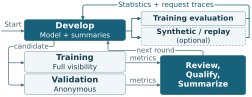

In [2]:
def draw() -> tuple[plt.Figure, list[tuple[object, tuple[float, ...]]]]:
    plt.rcParams.update({
        "font.family": "DejaVu Sans", "font.size": 7.2,
        "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
        "svg.hashsalt": "chia-loop-workflow-v10", "axes.unicode_minus": False,
    })
    fig = plt.figure(figsize=(WIDTH, HEIGHT), facecolor="white")
    ax = fig.add_axes((0, 0, 1, 1))
    ax.set(xlim=(0, WIDTH), ylim=(0, LAYOUT_HEIGHT))
    ax.axis("off")
    fitted = []

    def label(x, y, text, *, size=7.0, color=INK, weight="normal", ha="center", **kw):
        return ax.text(x, y, text, fontsize=size, color=color, fontweight=weight,
                       ha=ha, va="center", linespacing=1.25, zorder=4, **kw)

    def card(x, y, w, h, lines, *, fill="white", edge=LINE, color=INK, dashed=False):
        ax.add_patch(FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0,rounding_size=0.045",
            facecolor=fill, edgecolor=edge, linewidth=.65,
            linestyle=(0, (3, 2)) if dashed else "solid", zorder=2,
        ))
        for offset, text, size, weight in lines:
            artist = label(x + w / 2, y + offset, text, size=size, color=color, weight=weight)
            fitted.append((artist, (x, y, w, h)))

    def arrow(points, *, color=LINE, width=.75):
        ax.add_patch(FancyArrowPatch(
            path=elbow_path(points, radius=.04), arrowstyle="-|>", mutation_scale=6.0,
            linewidth=width, color=color, capstyle="round", joinstyle="round", zorder=1,
        ))

    # All simulation/evaluation nodes share one fill. Synthetic/replay tools use
    # Ramulator directly, so this color does not assert a common CPU frontend.
    card(1.96, 1.73, 1.45, .34, [
        (.17, "Training evaluation", 7.4, "bold"),
    ], fill=PALE, edge=BORDER)
    card(1.96, 1.25, 1.45, .44, [
        (.325, "Synthetic / replay", 7.4, "bold"),
        (.112, "(optional)", 7.0, "normal"),
    ], fill=PALE, edge=BORDER, dashed=True)
    # Put the tools beside Develop: a short fork replaces the tall diagnostic row.
    ax.plot([1.74, 1.83], [1.60, 1.60], color=TEAL, linewidth=.75,
            solid_capstyle="round", zorder=1)
    ax.plot([1.83, 1.83], [1.44, 1.90], color=TEAL, linewidth=.75,
            solid_capstyle="round", zorder=1)
    for y in (1.90, 1.44):
        arrow([(1.83, y), (1.96, y)], color=TEAL)
    # These are outputs, not another operation: join both tool outputs and label
    # the shared arrow that returns them to the developing agent.
    for y in (1.90, 1.44):
        ax.plot([3.41, 3.46], [y, y], color=TEAL, linewidth=.75,
                solid_capstyle="round", zorder=1)
    ax.plot([3.46, 3.46], [1.44, 1.90], color=TEAL, linewidth=.75,
            solid_capstyle="round", zorder=1)
    arrow([(3.46, 1.90), (3.46, 2.23), (1.15, 2.23), (1.15, 1.87)], color=TEAL)
    label(2.305, 2.23, "Statistics + request traces", size=7.2, color=TEAL,
          bbox={"facecolor": "white", "edgecolor": "none", "pad": .8})

    card(.34, 1.37, 1.40, .50, [
        (.35, "Develop", 8.5, "bold"),
        (.12, "Model + summaries", 7.0, "normal"),
    ], fill=TEAL, edge=TEAL, color="white")
    arrow([(.02, 1.60), (.34, 1.60)])
    label(.18, 1.75, "Start", size=7.0, color=MUTED)
    card(.34, .60, 1.40, .50, [
        (.35, "Training", 8.2, "bold"),
        (.12, "Full visibility", 7.2, "normal"),
    ], fill=PALE, edge=BORDER)
    card(.34, .06, 1.40, .50, [
        (.35, "Validation", 8.2, "bold"),
        (.12, "Anonymous", 7.2, "normal"),
    ], fill=PALE, edge=BORDER)

    # Full training visibility belongs to the proposer during development. The
    # independent review receives projected metrics and model sources, not the
    # underlying memory-request traces. Do not suggest otherwise on these edges.
    arrow([(.75, 1.37), (.75, 1.22), (.12, 1.22), (.12, .29), (.34, .29)])
    arrow([(.12, .83), (.34, .83)])
    label(.435, 1.22, "candidate", size=7.0, color=MUTED,
          bbox={"facecolor": "white", "edgecolor": "none", "pad": .4})
    card(2.23, .06, 1.18, .94, [
        (.47, "Review,\nQualify,\nSummarize", 8.0, "bold"),
    ], fill=TEAL, edge=TEAL, color="white")
    for y in (.83, .29):
        arrow([(1.74, y), (2.23, y)])
        label(1.985, y + .105, "metrics", size=7.0, color=MUTED)
    arrow([(2.82, 1.00), (2.82, 1.125), (1.50, 1.125), (1.50, 1.37)])
    label(2.16, 1.125, "next round", size=7.0, color=MUTED,
          bbox={"facecolor": "white", "edgecolor": "none", "pad": .6})
    return fig, fitted

with plt.rc_context():
    fig, fitted = draw()
    validate_layout(fig, fitted)
    for ext in ("svg", "pdf", "png"):
        if ext == "pdf":
            metadata = {"Title": "CHIA: development and independent promotion review",
                        "Subject": CAPTION, "CreationDate": None, "ModDate": None}
        elif ext == "svg":
            metadata = {"Title": "CHIA loop workflow", "Description": CAPTION, "Date": None}
        else:
            metadata = {"Title": "CHIA loop workflow", "Description": CAPTION}
        fig.savefig(OUTPUT / f"chia-loop-workflow.{ext}", dpi=400,
                    metadata=metadata, facecolor="white")
    display(SVG(filename=str(OUTPUT / "chia-loop-workflow.svg")))
    plt.close(fig)


## Fig. 2. Mean error (core-cycle, top plot, and $\mathrm{MAE}_{\mathrm{Req}}$, bottom plot) on the test set.

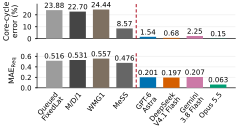

In [3]:
def foundation_accuracy(data: dict, output: Path) -> None:
    rows = {r["arm"]: r for r in data["tables"]["foundation_headlines"] if r["cohort"] == "test"}
    fig, axes = plt.subplots(2, 1, figsize=(COMPACT_WIDTH, 1.88), sharex=True)
    fig.subplots_adjust(left=.155, right=.985, bottom=.35, top=.97, hspace=.42)
    x = np.arange(len(ARMS))
    for ax, metric, title, limit in zip(axes, ("core_abs_pct", "mae_L"),
            ("Core-cycle\nerror (%)", r"$\mathrm{MAE}_{\mathrm{Req}}$"), (29, .66)):
        vals = [float(rows[a][metric]) for a in ARMS]
        ax.bar(x, vals, width=.70, color=[ADDITION_COLORS[a] for a in ARMS], zorder=3)
        for i, val in enumerate(vals):
            ax.text(i, val + limit * .025, f"{val:.2f}" if metric == "core_abs_pct" else f"{val:.3f}",
                    ha="center", va="bottom", fontsize=7)
        ax.set(ylim=(0, limit), ylabel=title)
        ax.set_yticks([0, 10, 20] if metric == "core_abs_pct" else [0, .2, .4, .6])
        ax.grid(axis="y", alpha=.18, zorder=0)
        ax.axvline(3.5, color="#B2182B", lw=1.05, ls=(0, (3, 2)), zorder=4)
        ax.tick_params(axis="x", length=0)
        ax.tick_params(axis="y", labelsize=7, length=2)
        ax.yaxis.label.set_size(7.5)
    axes[-1].set_xticks(x, [WRAPPED_NAMES[a] for a in ARMS], rotation=50, ha="right",
                       rotation_mode="anchor", fontsize=7, linespacing=1.0)
    check_figure_text(fig)
    save(fig, output, "foundation-accuracy")
    csv_table(output / "foundation-accuracy.csv", [{"model": NAMES[a], "cases": 24,
        "core_cycle_error_pct": float(rows[a]["core_abs_pct"]), "MAE_Req": float(rows[a]["mae_L"]),
        "oracle_pairing_coverage": float(rows[a]["oracle_coverage"])} for a in ARMS])

with plt.rc_context():
    style()
    foundation_accuracy(data, OUTPUT)


## Fig. 3. Evolution of simulation errors (core-cycle, top plots, log-scale, and $\mathrm{MAE}_{\mathrm{Req}}$, bottom plots) during the CHIA loops.

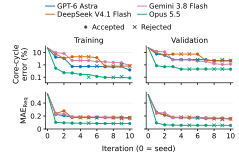

In [4]:
def foundation_convergence(data: dict, progression: dict, output: Path) -> None:
    from paper_checks import check_convergence
    if progression["paper_evidence_sha256"] != hashlib.sha256((BUNDLE_ROOT / "paper-evidence.json").read_bytes()).hexdigest():
        raise ValueError("Convergence belongs to another paper snapshot")
    check_convergence(progression, data["sources"], data["tables"]["foundation_headlines"])
    fig, axes = plt.subplots(2, 2, figsize=(COMPACT_WIDTH, 2.16), sharex=True, sharey="row")
    fig.subplots_adjust(left=.19, right=.975, bottom=.17, top=.705, wspace=.16, hspace=.25)
    campaigns = ("astra", "deepseek", "gemini", "opus")
    decisions = {(d["campaign"], d["round"]): d["promoted"] for d in progression["decisions"]}
    for i, metric in enumerate(("core_abs_pct", "mae_L")):
        for j, split in enumerate(("training", "validation")):
            ax = axes[i, j]
            for c in campaigns:
                color = ADDITION_COLORS[c + "_single_core"]
                chosen = sorted((r for r in progression["rows"] if r["campaign"] == c
                                 and r["split"] == split and r["kind"] == "retained"),
                                key=lambda r: r["round"])
                ax.plot([r["round"] for r in chosen], [r[metric] for r in chosen],
                        ls="-", lw=.9, color=color, label=NAMES[c + "_single_core"],
                        gid=f"{c}:chosen", zorder=2)
                for accepted, marker in ((True, "o"), (False, "x")):
                    proposed = sorted((r for r in progression["rows"] if r["campaign"] == c
                                       and r["split"] == split and r["kind"] == "submitted"
                                       and decisions[c, r["round"]] == accepted), key=lambda r: r["round"])
                    ax.plot([r["round"] for r in proposed], [r[metric] for r in proposed],
                            ls="none", marker=marker, ms=2.5 if accepted else 3.5,
                            mew=.6 if accepted else .8, color=color,
                            gid=f"{c}:{'accepted' if accepted else 'rejected'}", zorder=3 if accepted else 4)
            ax.set(xlim=(-.25, 10.3))
            ax.set_xticks([0, 2, 4, 6, 8, 10])
            ax.tick_params(labelsize=7, length=2, pad=2)
            ax.grid(axis="y", alpha=.18)
            if i == 0:
                ax.set(yscale="log", ylim=(.035, 35))
                ax.set_yticks([.1, 1, 10], ["0.1", "1", "10"])
                ax.minorticks_off()
                ax.set_title(split.capitalize(), fontsize=7.5, pad=3)
            else:
                ax.set(ylim=(0, .57))
                ax.set_yticks([0, .2, .4], ["0", "0.2", "0.4"])
    axes[0, 0].set_ylabel("Core-cycle\nerror (%)", fontsize=7.5, labelpad=2)
    axes[1, 0].set_ylabel(r"$\mathrm{MAE}_{\mathrm{Req}}$", fontsize=7.5, labelpad=2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(.53, 1.02), ncol=2,
               fontsize=7, frameon=False, handlelength=1.3, columnspacing=.9, handletextpad=.35, labelspacing=.2)
    decision_handles = [Line2D([], [], color="#444444", ls="none", marker="o", ms=2.5,
                               mew=.6, label="Accepted"),
                        Line2D([], [], color="#444444", ls="none", marker="x", ms=3.5,
                               mew=.8, label="Rejected")]
    fig.legend(handles=decision_handles, loc="upper center", bbox_to_anchor=(.53, .885), ncol=2,
               fontsize=7, frameon=False, handlelength=1.1, columnspacing=.9, handletextpad=.35)
    fig.text(.58, .028, "Iteration (0 = seed)", ha="center", fontsize=7.5)
    check_figure_text(fig)
    save(fig, output, "foundation-convergence")
    csv_table(output / "foundation-convergence.csv", progression["rows"])
    files = [output / ("foundation-convergence." + ext) for ext in ("pdf", "svg", "png", "csv")]
    manifest = {"schema": "paper-convergence-v1", "evidence": progression["notebook_evidence_sha256"],
                "payload_sha256": hashlib.sha256(json.dumps(progression, sort_keys=True, separators=(",", ":")).encode()).hexdigest(),
                "generator_sha256": hashlib.sha256(PLOTTING_SOURCE.read_bytes()).hexdigest(),
                "files": {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in files}}
    (output / "convergence-manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")

with plt.rc_context():
    style()
    foundation_convergence(data, progression, OUTPUT)


## Fig. 4. DRAM simulation speedup over the cycle-level oracle, by traffic pattern, read ratio, and request arrival interval. Each data point represents the median across five measurement repetitions.

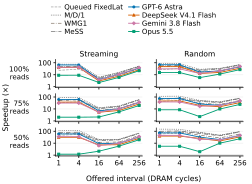

In [5]:
def foundation_speed(supplement: dict, output: Path) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(3.5, 2.58), sharex=True, sharey=True)
    fig.subplots_adjust(left=.22, right=.965, top=.68, bottom=.16, hspace=.22, wspace=.16)
    intervals = [1, 4, 16, 64, 256]
    styles = {"fixedlat": ("--", ""), "md1": (":", ""), "wmg1": ((0, (5, 2, 1, 2)), ""),
              "mess": ("-.", ""), "astra_single_core": ("-", "o"),
              "deepseek_single_core": ("-", "^"), "gemini_single_core": ("-", "D"),
              "opus_single_core": ("-", "s")}
    points = {(r["arm"], r["pattern"], r["read_percent"], r["interval"]): r
              for r in supplement["speed"] if r["arm"] != "oracle"}
    for j, read in enumerate((100, 75, 50)):
        for k, pattern in enumerate(("streaming", "random")):
            ax = axes[j, k]
            ax.axhline(1, color="#aaa", lw=.7, zorder=1)
            for arm in ARMS:
                vals = [points[arm, pattern, read, i]["oracle_relative_speedup"] for i in intervals]
                ls, marker = styles[arm]
                ax.plot(intervals, vals, label=NAMES[arm], color=ADDITION_COLORS[arm],
                        ls=ls, marker=marker, ms=2.0, lw=.7 if arm in ARMS[:4] else .9)
            ax.set(xscale="log", yscale="log", ylim=(.85, 190), xlim=(.8, 320))
            ax.set_xticks(intervals, [str(i) for i in intervals], fontsize=7)
            ax.set_yticks([1, 10, 100], ["1", "10", "100"], fontsize=7)
            ax.minorticks_off()
            ax.tick_params(length=2, pad=2)
            ax.grid(axis="y", alpha=.18)
            if j == 0:
                ax.set_title("Streaming" if pattern == "streaming" else "Random", fontsize=7.5, pad=3)
            if k == 0:
                ax.set_ylabel(f"{read}%\nreads", fontsize=7, rotation=0, labelpad=9,
                              ha="right", va="center")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(.53, 1.012), ncol=2,
               frameon=False, fontsize=7, columnspacing=.8, handlelength=1.5, labelspacing=.2, handletextpad=.4)
    fig.text(.57, .025, "Offered interval (DRAM cycles)", ha="center", fontsize=7.5)
    fig.text(.023, .42, "Speedup (×)", rotation=90, va="center", ha="center", fontsize=7.5)
    check_figure_text(fig)
    save(fig, output, "foundation-speed")
    fields = ("batch", "arm", "pattern", "read_percent", "interval", "n", "median", "oracle_relative_speedup")
    csv_table(output / "foundation-speed.csv", [{k: r[k] for k in fields} for r in supplement["speed"]])
    csv_table(output / "foundation-speed-summary.csv", [{"model": NAMES[a],
        "batch": next(r["batch"] for r in supplement["speed"] if r["arm"] == a), "traffic_points": 30,
        "geometric_mean_speedup": statistics.geometric_mean(r["oracle_relative_speedup"]
            for r in supplement["speed"] if r["arm"] == a)} for a in ARMS])

with plt.rc_context():
    style()
    foundation_speed(additions, OUTPUT)


## Fig. 5. Recorded LLM token usage (solid: input; hatched: output) and estimated API-equivalent LLM cost for all 10 iterations (log scales).

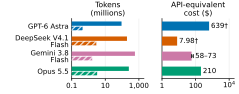

In [6]:
def foundation_usage(supplement: dict, output: Path) -> None:
    rows = {r["campaign"]: r for r in supplement["usage"]["tables"]["headline"]}
    campaigns = ["astra", "deepseek", "gemini", "opus"]
    colors = [ADDITION_COLORS[c + "_single_core"] for c in campaigns]
    fig, axes = plt.subplots(1, 2, figsize=(COMPACT_WIDTH, 1.40), sharey=True)
    fig.subplots_adjust(left=.30, right=.98, top=.77, bottom=.17, wspace=.25)
    y = np.arange(4)
    axes[0].barh(y - .16, [rows[c]["input_tokens"] / 1e6 for c in campaigns], height=.29,
                color=colors, label="Input", zorder=3)
    axes[0].barh(y + .16, [rows[c]["output_tokens"] / 1e6 for c in campaigns], height=.29,
                color=colors, hatch="////", edgecolor="white", lw=.5, label="Output", zorder=3)
    axes[0].set(xscale="log", xlim=(.1, 2000), ylim=(3.5, -.5))
    axes[0].set_xticks([.1, 10, 1000], ["0.1", "10", "1,000"])
    axes[0].set_title("Tokens\n(millions)", fontsize=7.5, pad=3)
    costs = [rows[c]["observed_cost_lower_usd"] for c in campaigns]
    axes[1].barh(y, costs, color=colors, height=.60, zorder=3)
    labels = ["639†", "7.98†", "58–73", "210"]
    for i, c in enumerate(campaigns):
        lo, hi = rows[c]["observed_cost_lower_usd"], rows[c]["observed_cost_upper_usd"]
        if hi - lo > .01:
            axes[1].errorbar(lo, i, xerr=[[0], [hi - lo]], capsize=2, color="#222", lw=.8, zorder=5)
        axes[1].text(hi * 1.3, i, labels[i], ha="left", va="center", fontsize=7)
    axes[1].set(xscale="log", xlim=(1, 20000))
    axes[1].set_xticks([1, 100, 10000], ["1", "100", r"$10^4$"])
    axes[1].set_title("API-equivalent\ncost ($)", fontsize=7.5, pad=3)
    labels = ["GPT-6 Astra", "DeepSeek V4.1\nFlash", "Gemini 3.8\nFlash", "Opus 5.5"]
    axes[0].set_yticks(y, labels, fontsize=7, linespacing=1.0)
    for ax in axes:
        ax.tick_params(axis="x", labelsize=7, length=2, pad=2)
        ax.tick_params(axis="y", length=0, pad=3)
        ax.minorticks_off()
        ax.grid(axis="x", alpha=.18, zorder=0)
    check_figure_text(fig)
    save(fig, output, "foundation-usage")
    csv_table(output / "foundation-usage.csv", [rows[c] for c in campaigns])

with plt.rc_context():
    style()
    foundation_usage(additions, OUTPUT)


## Fig. 6. gem5 accuracy of the models.

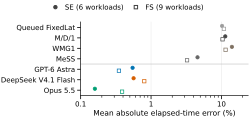

In [7]:
def extension_gem5(data: dict, output: Path) -> None:
    """Accuracy only: no host-runtime or simulator-speed data are plotted."""
    arms = ("fixedlat", "md1", "wmg1", "mess", "astra_single_core", "deepseek_single_core", "opus_single_core")
    groups = (("SE", "o", "SE (6 workloads)"), ("FS", "s", "FS (9 workloads)"))
    table = gem5_mode_means(data)
    fig, ax = plt.subplots(figsize=(3.5, 1.80))
    fig.subplots_adjust(left=.32, right=.985, bottom=.24, top=.81)
    for i, arm in enumerate(arms):
        for j, (mode, marker, _) in enumerate(groups):
            row = next(r for r in table if r["arm"] == arm and r["mode"] == mode)
            ax.plot(row["core_abs_pct"], i + (j - .5) * .28, marker=marker, ls="none",
                    ms=3.4, mew=.7, color=ADDITION_COLORS[arm],
                    mfc="white" if j == 1 else ADDITION_COLORS[arm], zorder=3)
    labels = [NAMES[a] for a in arms]
    ax.set_yticks(range(len(arms)), labels, fontsize=7)
    ax.set_ylim(len(arms)-.48, -.52)
    ax.set_xscale("log"); ax.set_xlim(.1, 24)
    ax.set_xticks([.1, 1, 10], ["0.1", "1", "10"])
    ax.set_xlabel("Mean absolute elapsed-time error (%)", fontsize=7.5, labelpad=2)
    ax.tick_params(axis="both", labelsize=7, pad=2)
    ax.grid(axis="x", which="major", color=".90", lw=.5)
    ax.axhline(3.5, color=".75", lw=.6)
    handles = [Line2D([], [], marker=m, ls="none", color=".25", ms=3.4,
                       mfc="white" if j == 1 else ".25", label=label)
               for j, (_, m, label) in enumerate(groups)]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .995), ncol=2,
               frameon=False, fontsize=7, handletextpad=.35, columnspacing=.75)
    check_figure_text(fig); save(fig, output, "extension-gem5")
    csv_table(output / "extension-gem5.csv", [{"model": NAMES[r["arm"]], "arm": r["arm"],
        "mode": r["mode"], "cases": r["cases"],
        "mean_absolute_elapsed_time_error_pct": r["core_abs_pct"]} for r in table])

with plt.rc_context():
    style()
    plt.rcParams.update({"font.size": 7.5, "axes.titlesize": 8, "axes.labelsize": 7.5,
                         "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7})
    extension_gem5(extensions, OUTPUT)


## Fig. 7. ChampSim accuracy after changing DRAM bank organizaiton and controller queue depth *without* retraining the model.

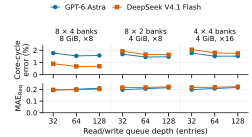

In [8]:
def extension_hardware(data: dict, output: Path) -> None:
    arms = ("astra_single_core", "deepseek_single_core")
    organizations = (("DDR5_16Gb_x8", "8 × 4 banks\n8 GiB, ×8"),
                     ("DDR5_8Gb_x8", "8 × 2 banks\n4 GiB, ×8"),
                     ("DDR5_16Gb_x16", "4 × 4 banks\n4 GiB, ×16"))
    table = data["headlines"]["hardware"]
    fig, axes = plt.subplots(2, 1, figsize=(3.5, 2.07), sharex=True)
    fig.subplots_adjust(left=.17, right=.985, bottom=.225, top=.68, hspace=.30)
    for ax, metric, label, limit in zip(axes, ("core_abs_pct", "mae_L"),
            ("Core-cycle\nerror (%)", r"$\mathrm{MAE}_{\mathrm{Req}}$"), (2.4, .25)):
        for j, (organization, _) in enumerate(organizations):
            for arm, marker in zip(arms, ("o", "s")):
                values = [next(r[metric] for r in table if r["arm"] == arm
                               and r["point"] == organization + "_q" + str(q)) for q in (32, 64, 128)]
                ax.plot(np.arange(3) + 3*j, values, marker=marker, ms=3.4, lw=.9,
                        color=ADDITION_COLORS[arm], label=NAMES[arm] if j == 0 else None, zorder=3)
        ax.set_ylim(0, limit); ax.set_xlim(-.45, 8.45)
        ax.set_ylabel(label, fontsize=7.5, labelpad=3)
        ax.grid(axis="y", color=".90", lw=.5)
        ax.tick_params(labelsize=7, pad=2)
        for x in (2.5, 5.5): ax.axvline(x, color=".75", lw=.6, ls=":")
    axes[0].set_yticks([0, 1, 2]); axes[1].set_yticks([0, .1, .2])
    for j, (_, label) in enumerate(organizations):
        axes[0].text(j*3+1, 1.10, label, transform=axes[0].get_xaxis_transform(),
                     ha="center", va="bottom", fontsize=7, linespacing=1.1)
    axes[1].set_xticks(range(9), ["32", "64", "128"] * 3)
    axes[1].set_xlabel("Read/write queue depth (entries)", fontsize=7.5, labelpad=3)
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(.5, 1),
               ncol=2, frameon=False, fontsize=7, handlelength=1.2, columnspacing=1)
    check_figure_text(fig); save(fig, output, "extension-hardware")
    csv_table(output / "extension-hardware.csv", [{"model": NAMES[r["arm"]], **r} for r in table])

with plt.rc_context():
    style()
    plt.rcParams.update({"font.size": 7.5, "axes.titlesize": 8, "axes.labelsize": 7.5,
                         "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7})
    extension_hardware(extensions, OUTPUT)


## Fig. 8. Multicore errors, averaging eight test mixes separately at four and eight cores. Open/filled model markers denote synthesis after 10 single-core iterations/5 additional multicore iterations. Baselines have one result per core count; fill has no stage meaning for them.

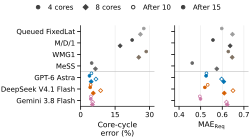

In [9]:
def extension_multicore(data: dict, output: Path) -> None:
    arms = ("fixedlat", "md1", "wmg1", "mess", "astra", "deepseek", "gemini")
    table = data["headlines"]["multicore"]
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.02), sharey=True)
    fig.subplots_adjust(left=.32, right=.985, bottom=.25, top=.805, wspace=.28)
    for ax, metric, label, limits, ticks in zip(axes, ("core_abs_pct", "mae_L"),
            ("Core-cycle\nerror (%)", r"$\mathrm{MAE}_{\mathrm{Req}}$"), ((0, 32), (.38, .72)),
            ([0, 15, 30], [.4, .5, .6, .7])):
        for i, arm in enumerate(arms):
            is_model = arm in ("astra", "deepseek", "gemini")
            color = ADDITION_COLORS[arm + "_single_core" if is_model else arm]
            for cores, marker in ((4, "o"), (8, "D")):
                stages = ("single_core", "multicore") if is_model else (None,)
                for stage in stages:
                    name = arm + "_" + stage if stage else arm
                    row = next(r for r in table if r["arm"] == name and r["cores"] == cores)
                    offset = (-.25 if cores == 4 else .25) + ((-.11 if stage == "single_core" else .11) if stage else 0)
                    ax.plot(row[metric], i + offset, marker=marker, ls="none", ms=2.8, mew=.75,
                            color=color, mfc="white" if stage == "single_core" else color, zorder=3)
        ax.set(xlim=limits, xticks=ticks, ylim=(len(arms)-.5, -.5))
        ax.set_xlabel(label, fontsize=7.5, labelpad=3)
        ax.tick_params(labelsize=7, pad=2)
        ax.grid(axis="x", color=".90", lw=.5)
        ax.axhline(3.5, color=".75", lw=.6)
    names = [NAMES[a + "_single_core" if a in ("astra", "deepseek", "gemini") else a] for a in arms]
    axes[0].set_yticks(range(len(arms)), names, fontsize=7)
    handles = [Line2D([], [], marker=m, ls="none", color=".25", ms=3.5, mfc=fill, label=label)
        for m, fill, label in (("o", ".25", "4 cores"), ("D", ".25", "8 cores"),
                               ("o", "white", "After 10"), ("o", ".25", "After 15"))]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .995), ncol=4,
               frameon=False, fontsize=7, columnspacing=.75, handletextpad=.4)
    check_figure_text(fig); save(fig, output, "extension-multicore")
    csv_table(output / "extension-multicore.csv", [{"model": NAMES[r["arm"].replace("_multicore", "_single_core")],
        "stage": "after_15" if r["arm"].endswith("_multicore") else
                 ("after_10" if r["arm"].endswith("_single_core") else "baseline"), **r} for r in table])

with plt.rc_context():
    style()
    plt.rcParams.update({"font.size": 7.5, "axes.titlesize": 8, "axes.labelsize": 7.5,
                         "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7})
    extension_multicore(extensions, OUTPUT)

# Reconcile all exported source tables with the paper snapshot.
export_report = verify_exports(ROOT, OUTPUT, manifest)
